# DL Lab 1

Project notebook using the local `venv` kernel.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
iris = load_iris()
X = pd.DataFrame(iris.data,columns=iris.feature_names)
y = iris.target
target_names = iris.target_names
print("Data loaded successfully")
display(X.head())

Data loaded successfully


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("features standardized")


features standardized


In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
variance_retained = sum(pca.explained_variance_ratio_)*100

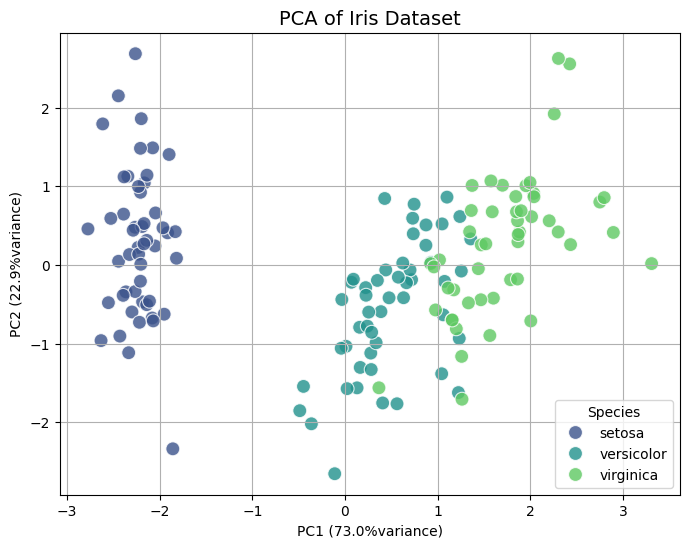

In [9]:
pca_df = pd.DataFrame(data =X_pca,columns =['Principal Component 1','Principal Component 2'])
pca_df['species'] = [target_names[label] for label in y]
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Principal Component 1',
    y ='Principal Component 2',
    hue='species',
    palette ='viridis',
    data =pca_df,
    s=100,
    alpha =0.8
)
plt.title('PCA of Iris Dataset',fontsize =14)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%variance)")
plt.legend(title ='Species')
plt.grid(True)
plt.show()